# Modeling Malware Spread on Computer Networks Using Differential Equations
**Final Project Code**
**Author:** Zeal Shah

**Description:** This notebook simulates malware transmission using SIR and SIRS differential equation frameworks. It covers numerical integration using `scipy.integrate.odeint`, phase portraits, bifurcation analysis, and parameter sensitivity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13

## 1. Defining the Differential Equations
Here we set up the system of ODEs that govern the change in device states over time for both the base SIR model (permanent patches) and the modified SIRS model (expiring patches).

In [2]:
def sir_model(y, t, beta, gamma):
    """Base model: Permanent recovery."""
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

def sirs_model(y, t, beta, gamma, mu):
    """Modified model: Patches expire at rate mu."""
    S, I, R = y
    dSdt = -beta * S * I + mu * R
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I - mu * R
    return [dSdt, dIdt, dRdt]

# Global initial conditions: 99% susceptible, 1% infected
y0 = [0.99, 0.01, 0.0]
t = np.linspace(0, 50, 500) # 50 days of simulation

## Visualization 1: Time-Series Graphs (S, I, R vs. Time)
Comparing the physical spread of the malware under three different $R_0$ regimes: decay, slow growth, and aggressive outbreak.

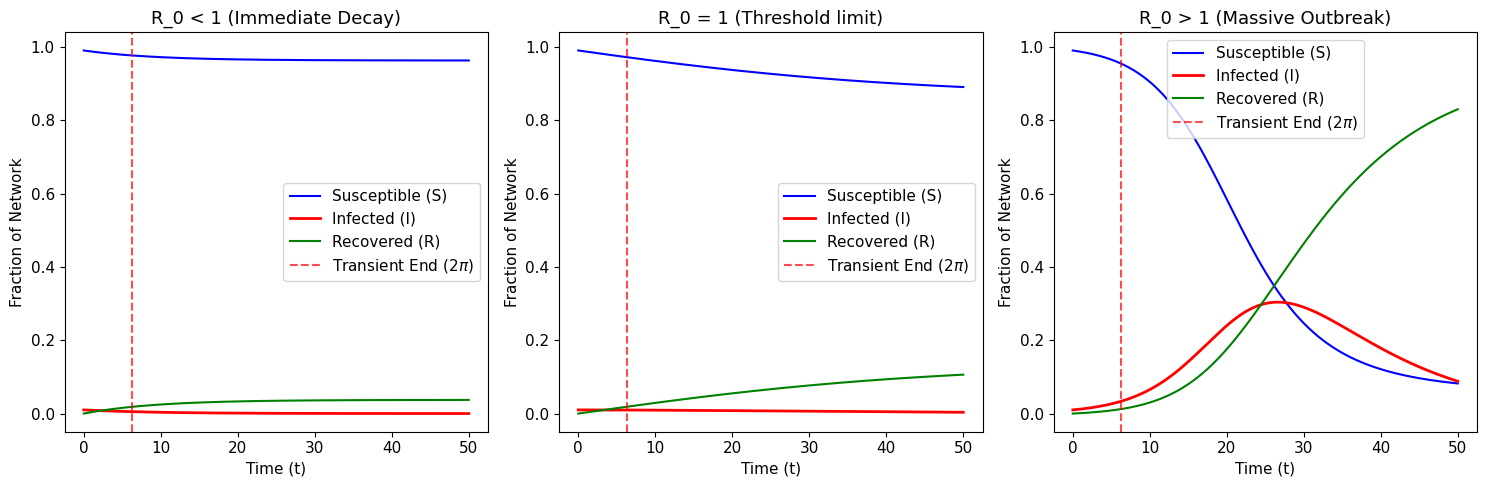

In [ ]:
# --- VISUALIZATION 1: TIME SERIES ---
fig1, axes = plt.subplots(1, 3, figsize=(15, 5))

scenarios = [(0.3, 0.4), (0.3, 0.3), (0.3, 0.1)] 
titles = ['R_0 < 1 (Immediate Decay)', 'R_0 = 1 (Threshold limit)', 'R_0 > 1 (Massive Outbreak)']

for i, (beta, gamma) in enumerate(scenarios):
    sol = odeint(sir_model, y0, t, args=(beta, gamma))
    axes[i].plot(t, sol[:, 0], 'b-', label='Susceptible (S)')
    axes[i].plot(t, sol[:, 1], 'r-', linewidth=2, label='Infected (I)')
    axes[i].plot(t, sol[:, 2], 'g-', label='Recovered (R)')
    
    axes[i].axvline(2*np.pi, color='red', linestyle='--', alpha=0.7, label=r'Transient End ($2\pi$)')
    
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Time (t)')
    axes[i].set_ylabel('Fraction of Network')
    axes[i].legend()

plt.tight_layout()
plt.show()

## Visualization 2: Phase Portrait
Mapping the direction field in the S-I plane to show how varying initial infection sizes all flow toward the Disease-Free equilibrium on the horizontal axis.

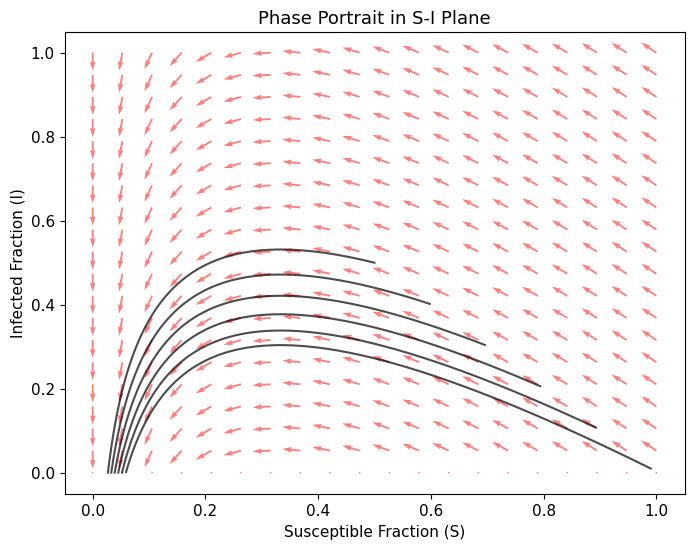

In [ ]:
# --- VISUALIZATION 2: PHASE PORTRAIT ---
fig2, ax = plt.subplots(figsize=(8, 6))
beta, gamma = 0.3, 0.1

S_grid, I_grid = np.meshgrid(np.linspace(0, 1, 20), np.linspace(0, 1, 20))
dS = -beta * S_grid * I_grid
dI = beta * S_grid * I_grid - gamma * I_grid

norm = np.hypot(dS, dI)
norm[norm == 0] = 1 
ax.quiver(S_grid, I_grid, dS/norm, dI/norm, color='red', alpha=0.5)

for I0 in np.linspace(0.01, 0.5, 6):
    sol = odeint(sir_model, [1-I0, I0, 0], np.linspace(0, 100, 1000), args=(beta, gamma))
    ax.plot(sol[:, 0], sol[:, 1], 'k-', alpha=0.7)

ax.set_xlabel('Susceptible Fraction (S)')
ax.set_ylabel('Infected Fraction (I)')
ax.set_title('Phase Portrait in S-I Plane')
plt.show()

## Visualization 3: Bifurcation Diagram
Sweeping the patching rate ($\gamma$) to find the exact transcritical bifurcation point where the malware stops sustaining an endemic infection.

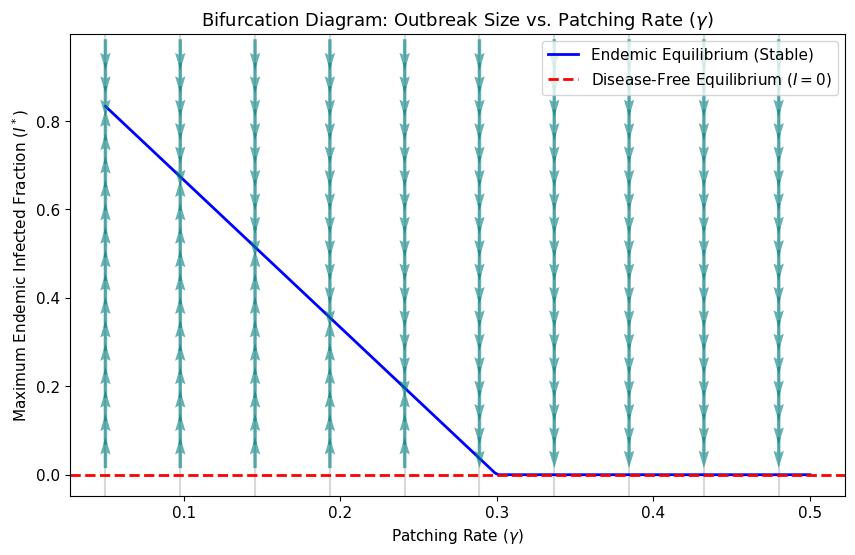

In [ ]:
# --- VISUALIZATION 3: BIFURCATION DIAGRAM (DYNAMIC PHASE LINES) ---
fig3, ax = plt.subplots(figsize=(10, 6))

gamma_vals = np.linspace(0.05, 0.5, 200)
beta = 0.3

I_max = [max(0, 1 - g/beta) for g in gamma_vals]

ax.plot(gamma_vals, I_max, 'b-', linewidth=2, label='Endemic Equilibrium (Stable)')
ax.axhline(0, color='red', linewidth=2, linestyle='--', label=r'Disease-Free Equilibrium ($I=0$)')

# --- DYNAMIC VECTOR FIELD  ---

phase_gammas = np.linspace(0.05, 0.48, 10) 
I_points = np.linspace(0.05, 0.95, 18)   
G_grid, I_grid = np.meshgrid(phase_gammas, I_points)

dI = I_grid * ((1 - G_grid/beta) - I_grid)
dG = np.zeros_like(G_grid) 

norm = np.abs(dI)
norm[norm == 0] = 1 
dI_direction = dI / norm

ax.quiver(G_grid, I_grid, dG, dI_direction, color='teal', pivot='mid', scale=25, alpha=0.6, zorder=2)

for g in phase_gammas:
    ax.axvline(g, color='gray', linestyle='-', alpha=0.3, zorder=1)

ax.set_xlabel(r'Patching Rate ($\gamma$)')
ax.set_ylabel(r'Maximum Endemic Infected Fraction ($I^*$)')
ax.set_title(r'Bifurcation Diagram: Outbreak Size vs. Patching Rate ($\gamma$)')
ax.legend(loc='upper right')

plt.show()

## Visualization 4: Sensitivity Heat-map
Testing the sensitivity of the network to changes in BOTH the infection rate ($\beta$) and patching rate ($\gamma$) simultaneously.

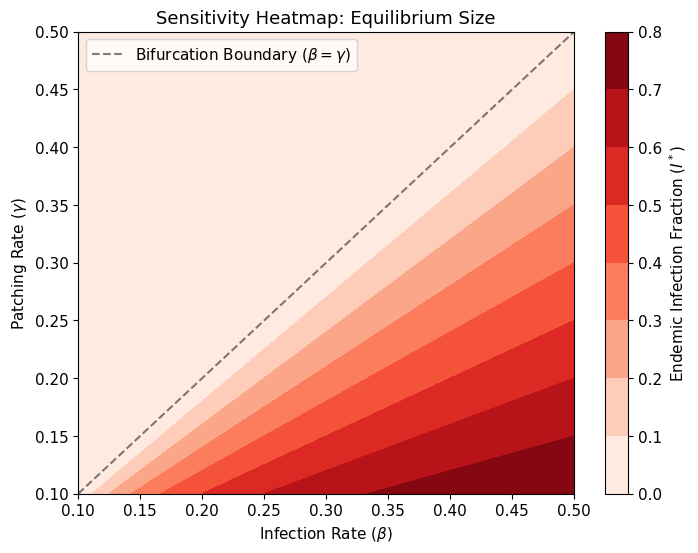

In [ ]:
# --- VISUALIZATION 4: SENSITIVITY HEAT-MAP ---
fig4, ax = plt.subplots(figsize=(8, 6))

beta_vals = np.linspace(0.1, 0.5, 100)
gamma_vals_hm = np.linspace(0.1, 0.5, 100)
B, G = np.meshgrid(beta_vals, gamma_vals_hm)

I_eq = np.maximum(0, 1 - G/B)

c = ax.contourf(B, G, I_eq, cmap='Reds')
fig4.colorbar(c, ax=ax, label='Endemic Infection Fraction ($I^*$)')

ax.plot([0.1, 0.5], [0.1, 0.5], 'k--', alpha=0.5, label=r'Bifurcation Boundary ($\beta = \gamma$)')
ax.set_xlabel('Infection Rate ($\\beta$)')
ax.set_ylabel(r'Patching Rate ($\gamma$)')
ax.set_title('Sensitivity Heatmap: Equilibrium Size')
ax.legend()
plt.show()

## Visualization 5: SIR vs. SIRS Comparison
Overlaying the base model against the modified model to prove how patch expiration ($\mu$) creates a permanent endemic equilibrium.

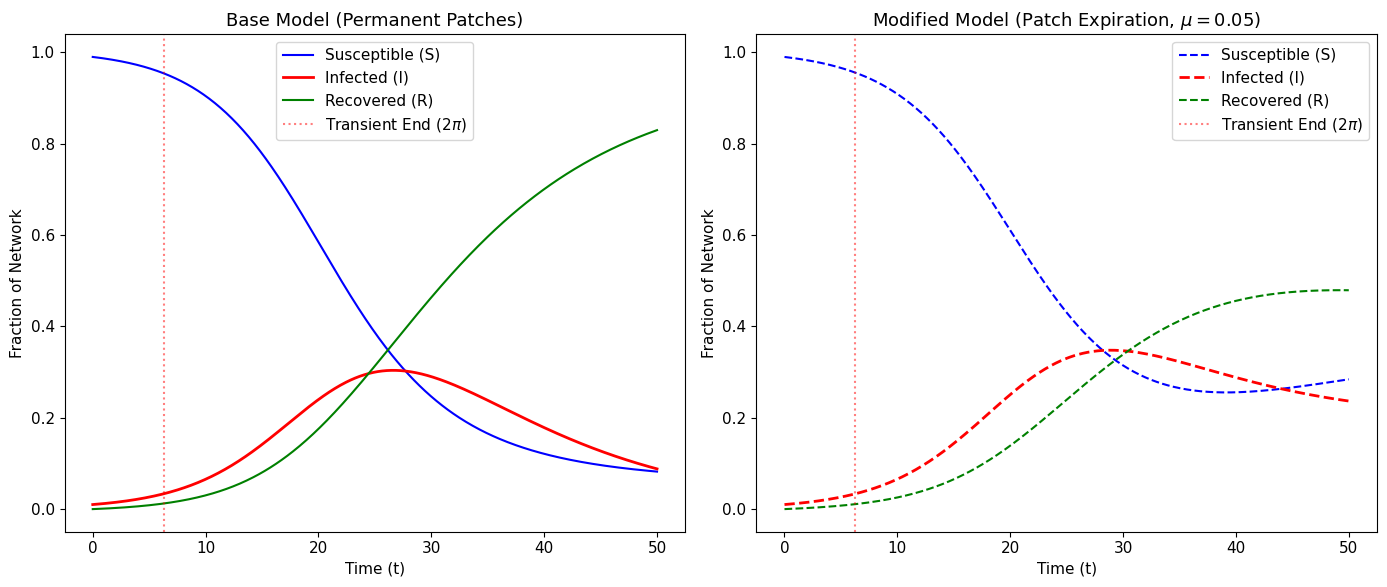

In [ ]:
# --- VISUALIZATION 5: SIR VS SIRS COMPARISON (ALL COMPARTMENTS) ---
fig5, axes = plt.subplots(1, 2, figsize=(14, 6))

sol_sir = odeint(sir_model, y0, t, args=(0.3, 0.1))
sol_sirs = odeint(sirs_model, y0, t, args=(0.3, 0.1, 0.05))

# LEFT PANEL: Base SIR Model
axes[0].plot(t, sol_sir[:, 0], 'b-', label='Susceptible (S)')
axes[0].plot(t, sol_sir[:, 1], 'r-', linewidth=2, label='Infected (I)')
axes[0].plot(t, sol_sir[:, 2], 'g-', label='Recovered (R)')
axes[0].axvline(2*np.pi, color='red', linestyle=':', alpha=0.5, label=r'Transient End ($2\pi$)')

axes[0].set_title('Base Model (Permanent Patches)')
axes[0].set_xlabel('Time (t)')
axes[0].set_ylabel('Fraction of Network')
axes[0].legend()

# RIGHT PANEL: Modified SIRS Model
axes[1].plot(t, sol_sirs[:, 0], 'b--', label='Susceptible (S)')
axes[1].plot(t, sol_sirs[:, 1], 'r--', linewidth=2, label='Infected (I)')
axes[1].plot(t, sol_sirs[:, 2], 'g--', label='Recovered (R)')
axes[1].axvline(2*np.pi, color='red', linestyle=':', alpha=0.5, label=r'Transient End ($2\pi$)')

axes[1].set_title(r'Modified Model (Patch Expiration, $\mu=0.05$)')
axes[1].set_xlabel('Time (t)')
axes[1].set_ylabel('Fraction of Network')
axes[1].legend()

plt.tight_layout()
plt.show()